In [1]:
import torch
from torch import nn
from torchvision import transforms
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

import requests

import cv2


In [2]:
# Remove the sample_data folder from google colab
!rm -rf /content/*
!git clone https://github.com/GiaHuyPham/DeepLearning_ComputerVision.git

Cloning into 'DeepLearning_ComputerVision'...
remote: Enumerating objects: 3029, done.
remote: Counting objects: 100% (774/774), done.
remote: Compressing objects: 100% (760/760), done.
remote: Total 3029 (delta 45), reused 13 (delta 13), pack-reused 2255 (from 3)
Receiving objects: 100% (3029/3029), 129.86 MiB | 18.98 MiB/s, done.
Resolving deltas: 100% (171/171), done.


## Clean up file tree

In [3]:
import shutil
import os

""" Clean up the file tree"""

# Create new folder for the train data
os.makedirs("/content/data",exist_ok=True)
os.makedirs("/content/unseen_data",exist_ok=True)
# Create saving path
os.makedirs("/content/output",exist_ok=True)
os.makedirs("/content/output/model",exist_ok=True)
os.makedirs("/content/output/plots",exist_ok=True)
os.makedirs("/content/output/pred_masks",exist_ok=True)

# Move the image folder and mask folder to new folder
shutil.move("/content/DeepLearning_ComputerVision/images","/content/data/images")
shutil.move("/content/DeepLearning_ComputerVision/images_unseen","/content/unseen_data/images_unseen")
shutil.move("/content/DeepLearning_ComputerVision/masks","/content/data/masks")
shutil.move("/content/DeepLearning_ComputerVision/masks_unseen","/content/unseen_data/masks_unseen")

shutil.move("/content/DeepLearning_ComputerVision/pyunet","/content/pyunet")

# Delete unnessary files and folders
shutil.rmtree("/content/DeepLearning_ComputerVision")

# Check if folders are there?
print(os.listdir('/content/data'))

['masks', 'images']


## Define File Paths

In [4]:
# Define the base path
DATASET_PATH = os.path.join("/content","data")

# Define Image and Mask path
IMAGE_DATASET_PATH = os.path.join(DATASET_PATH,"images")
MASKS_DATASET_PATH = os.path.join(DATASET_PATH,"masks")

# Device agnostic

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Initialize Hyperparameters

In [6]:
# Define input channels, number of classes, number of levels for the model
NUM_CHANNELS = 1
NUM_CLASSES = 1
NUM_LEVELS = 3

# Define number of epochs, learning rate, and batch size
LR = 0.001
BATCH_SIZE = 64
THRESHOLD = 0.5

# Define image input shape
INPUT_IMAGE_HEIGHT = 128
INPUT_IMAGE_WIDTH = 128

# define the test split
TEST_SPLIT = 0.15

In [7]:
from pathlib import Path
from imutils import paths
from pyunet.SegmentationDataset import SegmentationDataset
from torchvision.transforms import InterpolationMode
from sklearn.model_selection import train_test_split

# Prepare data

In [8]:
# Check if file path work
imagePath = sorted(list(paths.list_images(IMAGE_DATASET_PATH))) # Path to all the image files
maskPath = sorted(list(paths.list_images(MASKS_DATASET_PATH))) # Path to all the mask files

# Split training and testing dataset
trainImages,testImages,trainMasks,testMasks = train_test_split(imagePath,
                                                               maskPath,
                                                               test_size=TEST_SPLIT,
                                                               random_state=42)

# Write a transform for image
image_transform = transforms.Compose([
    # Transfrom to PILimage
    transforms.ToPILImage(),
    # Resize our image
    transforms.Resize(size=(INPUT_IMAGE_HEIGHT,INPUT_IMAGE_WIDTH)),
    # Turn image into tensor
    transforms.ToTensor()
])

mask_transform = transforms.Compose([
    # Transfrom to PILimage
    transforms.ToPILImage(),
    # Resize our image
    transforms.Resize(size=(INPUT_IMAGE_HEIGHT,INPUT_IMAGE_WIDTH),
                      interpolation=InterpolationMode.NEAREST),
    # Turn image into tensor
    transforms.ToTensor()
])
trainDS = SegmentationDataset(trainImages,trainMasks,image_transform,mask_transform)
testDS = SegmentationDataset(testImages,testMasks,image_transform,mask_transform)

print(f"[INFO] found {len(trainDS)} examples in the training set...")
print(f"[INFO] found {len(testDS)} examples in the test set...")

# Create dataloader
trainDL = DataLoader(dataset=trainDS,
                     batch_size=BATCH_SIZE,
                     shuffle=True)
testDL = DataLoader(dataset=testDS,
                    batch_size=BATCH_SIZE,
                    shuffle=False)

[INFO] found 646 examples in the training set...
[INFO] found 114 examples in the test set...


In [9]:
train_img_batch,train_mask_batch = next(iter(trainDL))
train_img_batch.shape,train_mask_batch.shape

(torch.Size([64, 1, 128, 128]), torch.Size([64, 1, 128, 128]))

In [10]:
train_img_batch.dtype

torch.float32

# Prepare for training

In [11]:
# Create an instance for the unet model
from pyunet.Unet import Unet
model_test = Unet().to(device)

In [12]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1e-8):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits, targets):

        probs = torch.sigmoid(logits)

        intersection = (probs * targets).sum(dim=(1,2,3))
        union = probs.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3))

        dice = (2 * intersection + self.smooth) / (union + self.smooth)

        return 1 - dice.mean()



In [13]:
# class BinaryDiceLoss(nn.Module):
#     """Adapted from MulticlassDiceLoss for binary classification.
#     Reference: https://www.kaggle.com/code/bigironsphere/loss-function-library-keras-pytorch#Dice-Loss
#     """
#     def __init__(self, sigmoid=True):
#         super().__init__()
#         self.sigmoid = sigmoid

#     def forward(self, logits, targets, reduction='mean', smooth=1e-6):
#         """
#         Args:
#             logits: Raw model output of shape (N, 1, H, W) or (N, H, W)
#             targets: Binary ground truth of shape (N, H, W), values in {0, 1}
#         """
#         probabilities = torch.sigmoid(logits) if self.sigmoid else logits

#         # Flatten to (N, -1) for easier computation
#         probabilities = probabilities.view(probabilities.size(0), -1)
#         targets_flat  = targets.view(targets.size(0), -1).float()

#         intersection = (probabilities * targets_flat).sum(dim=1)

#         mod_a = probabilities.sum(dim=1)
#         mod_b = targets_flat.sum(dim=1)

#         dice_coefficient = (2. * intersection + smooth) / (mod_a + mod_b + smooth)
#         dice_loss = -dice_coefficient.log()

#         if reduction == 'mean':
#             return dice_loss.mean()
#         elif reduction == 'sum':
#             return dice_loss.sum()
#         else:
#             return dice_loss


# # --- Test ---
# criterion = BinaryDiceLoss(sigmoid=True)
# y            = torch.randn(10, 1, 4, 4)       # (N, 1, H, W) logits
# ground_truth = torch.randint(0, 2, (10, 4, 4)) # binary targets
# print(y.shape)
# print(criterion(y, ground_truth))

In [14]:
class BinaryDiceLoss(nn.Module):
    def __init__(self, sigmoid=True, smooth=1e-6):
        super().__init__()
        self.sigmoid = sigmoid
        self.smooth = smooth

    def forward(self, logits, targets):

        probs = torch.sigmoid(logits) if self.sigmoid else logits

        if targets.dim() == 3:
            targets = targets.unsqueeze(1)

        probs = probs.view(probs.size(0), -1)
        targets = targets.view(targets.size(0), -1).float()

        intersection = (probs * targets).sum(dim=1)
        union = probs.sum(dim=1) + targets.sum(dim=1)

        dice = (2 * intersection + self.smooth) / (union + self.smooth)

        return 1 - dice.mean()

In [15]:
class CombinedLoss(nn.Module):
    def __init__(self):
        super().__init__()

        self.register_buffer("pos_weight", torch.tensor([5.0],device="cuda"))

        self.bce = nn.BCEWithLogitsLoss(pos_weight=self.pos_weight)
        self.dice = DiceLoss()

    def forward(self, logits, targets):

        bce_loss = self.bce(logits, targets)
        dice_loss = self.dice(logits, targets)

        return 0.3*bce_loss + 1.7*dice_loss

In [16]:
# Define loss function and optimizer
loss_fn = nn.BCEWithLogitsLoss()
# pos_weight = torch.tensor([2.0],device="cuda")
# loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
# loss_fn = BinaryDiceLoss(sigmoid=True)
# loss_fn = CombinedLoss()
optimizer = torch.optim.Adam(params=model_test.parameters(),
                             lr=LR)



In [17]:
# Initialize variables
epochs = 200
H = {
    "train_loss":[],
    "train_acc":[],
    "test_loss":[],
    "test_acc":[]
}

# It's training time!!!

In [18]:
from timeit import default_timer as timer
from pyunet.helperfunctions import print_train_time
from pyunet.helperfunctions import train_step
from pyunet.helperfunctions import test_step
from pyunet.helperfunctions import dice_score
from tqdm.auto import tqdm

In [19]:
start_train_time = timer()
print("[INFO] Network is training....")
for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-----")
  train_loss,train_acc = train_step(data_loader=trainDL,
             model=model_test,
             loss_fn=loss_fn,
             optimizer=optimizer,
             metric_fn=dice_score,
             device=device)

  test_loss,test_acc = test_step(
      data_loader=testDL,
      model=model_test,
      loss_fn=loss_fn,
      metric_fn=dice_score,
      device=device
  )

  # Assign value
  # H["train_loss"].append(train_loss.cpu().detach().numpy())
  # H["train_acc"].append(train_acc.cpu().detach().numpy())
  # H["test_loss"].append(test_loss.cpu().detach().numpy())
  # H["test_acc"].append(test_acc.cpu().detach().numpy())
  H["train_loss"].append(train_loss)
  H["train_acc"].append(train_acc)
  H["test_loss"].append(test_loss)
  H["test_acc"].append(test_acc)
  print(f"\nTrain loss: {train_loss:.4f} | Test loss: {test_loss:.4f} | Train DiceScore: {train_acc:.4f} | Test DiceScore: {test_acc:.4f}")

end_train_time = timer()
total_train_time = print_train_time(start=start_train_time,
                                    end=end_train_time,device=device)


[INFO] Network is training....


  0%|          | 0/200 [00:00<?, ?it/s]

Epoch: 0
-----

Train loss: 0.6930 | Test loss: 0.6767 | Train DiceScore: 0.2832 | Test DiceScore: 0.0000
Epoch: 1
-----

Train loss: 0.6676 | Test loss: 0.6231 | Train DiceScore: 0.2392 | Test DiceScore: 0.2855
Epoch: 2
-----

Train loss: 0.6183 | Test loss: 0.6640 | Train DiceScore: 0.5613 | Test DiceScore: 0.5437
Epoch: 3
-----

Train loss: 0.6380 | Test loss: 0.6107 | Train DiceScore: 0.5213 | Test DiceScore: 0.4962
Epoch: 4
-----

Train loss: 0.6287 | Test loss: 0.5944 | Train DiceScore: 0.4835 | Test DiceScore: 0.5051
Epoch: 5
-----

Train loss: 0.6113 | Test loss: 0.5910 | Train DiceScore: 0.5164 | Test DiceScore: 0.5053
Epoch: 6
-----

Train loss: 0.5948 | Test loss: 0.5996 | Train DiceScore: 0.5157 | Test DiceScore: 0.4016
Epoch: 7
-----

Train loss: 0.6058 | Test loss: 0.5916 | Train DiceScore: 0.5006 | Test DiceScore: 0.4529
Epoch: 8
-----

Train loss: 0.6052 | Test loss: 0.5856 | Train DiceScore: 0.4941 | Test DiceScore: 0.5051
Epoch: 9
-----

Train loss: 0.6079 | Test loss

# Evaluate the model

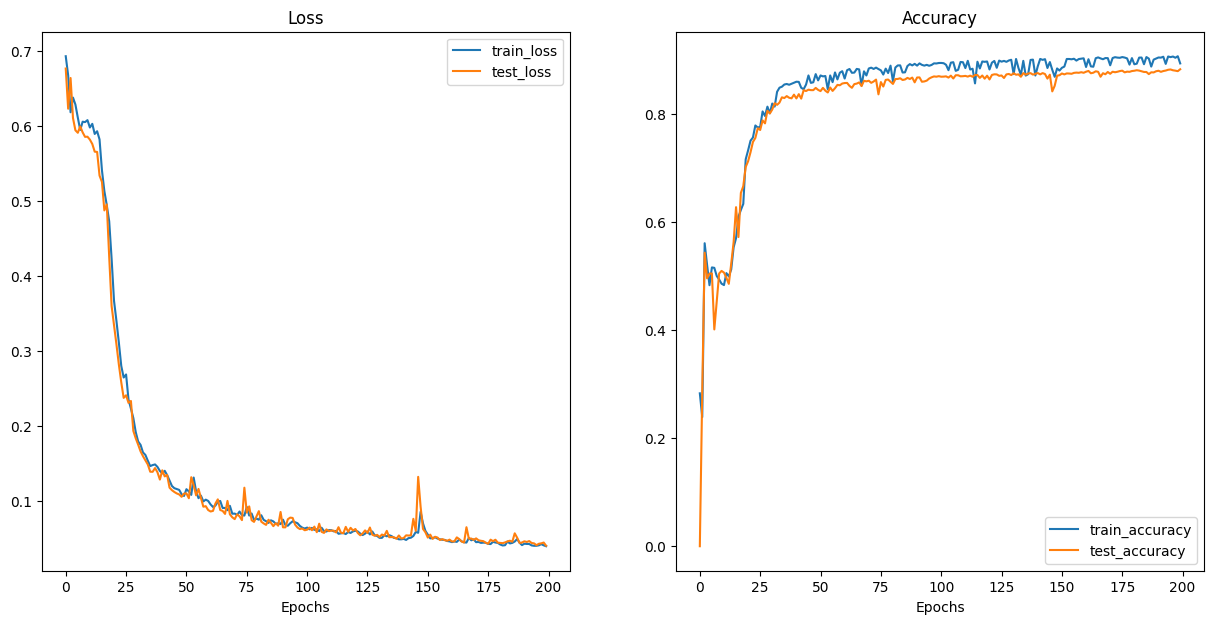

In [20]:
from pyunet.helperfunctions import plot_loss_curves
import matplotlib.pyplot as plt


# Create plots folder
plots_path = '/content/output/plots'

# Plot and save
plot_loss_curves(H)
plt.savefig(os.path.join(plots_path, 'loss_accuracy_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

## Predictions on test data

In [21]:
import numpy as np


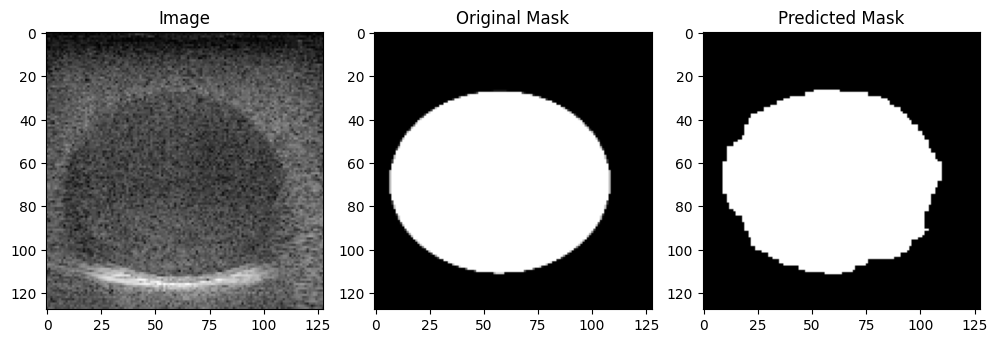

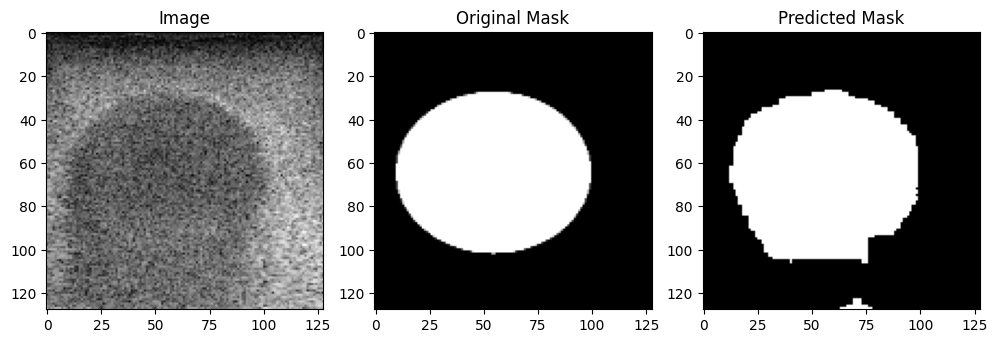

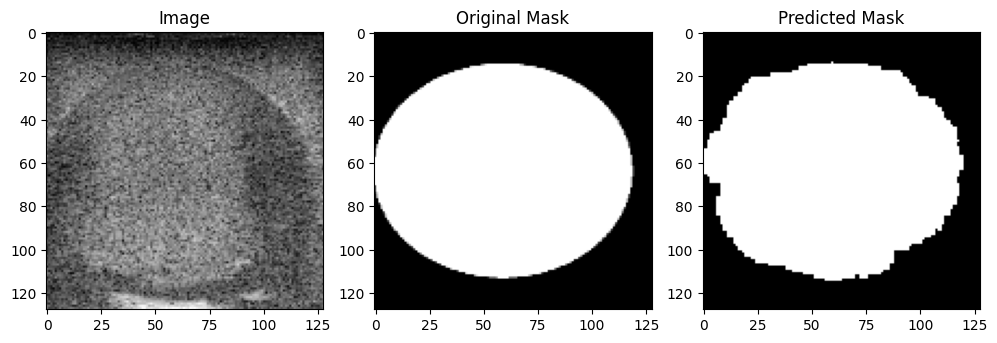

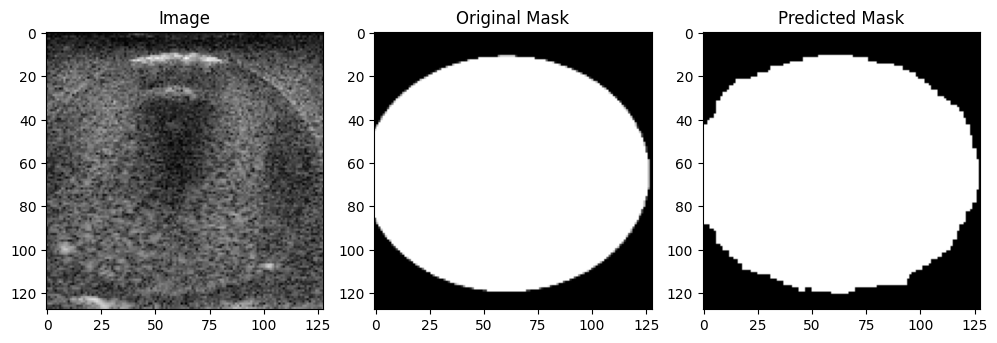

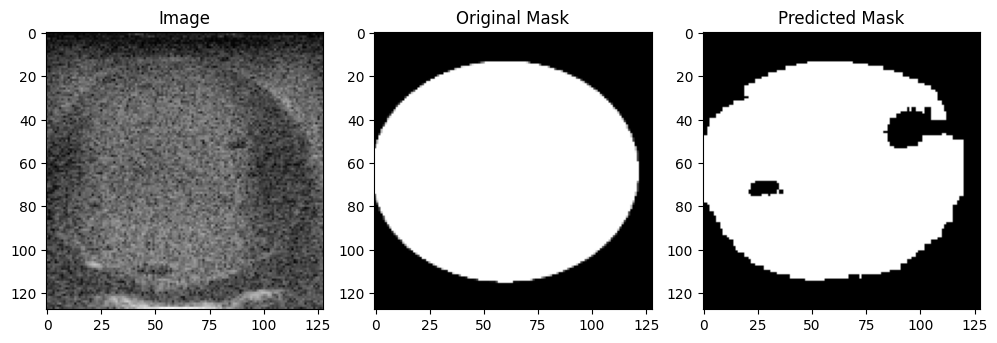

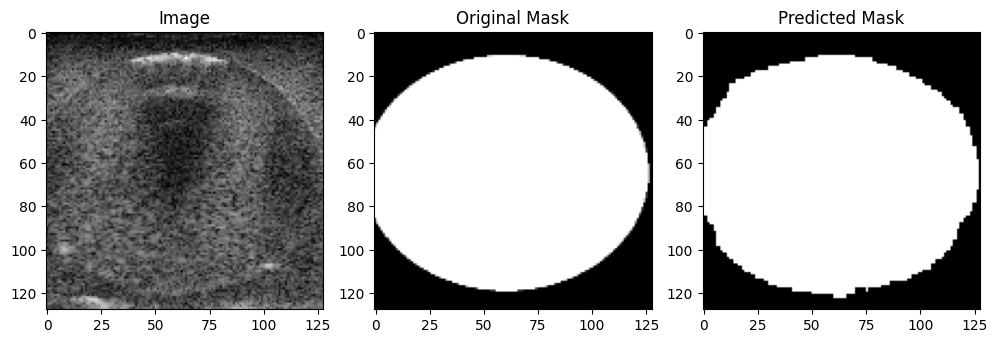

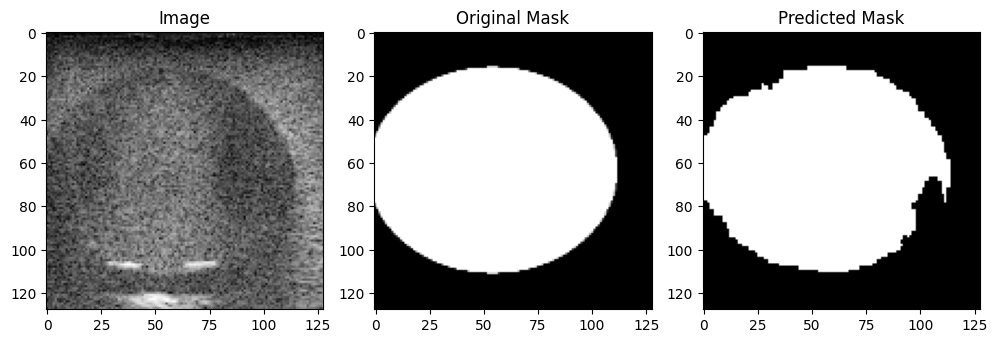

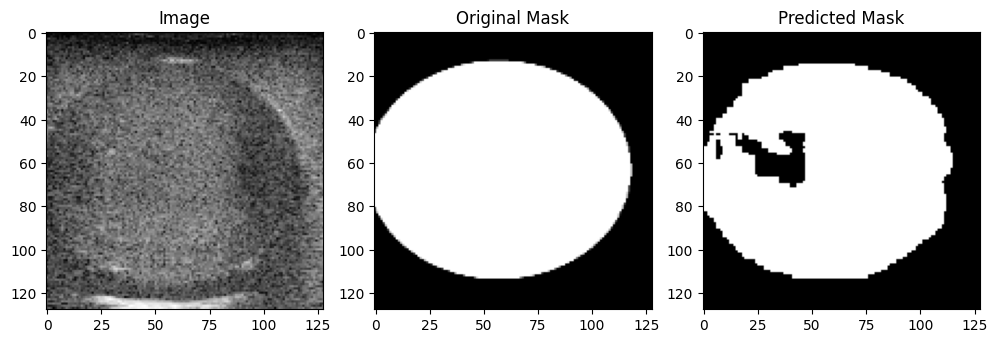

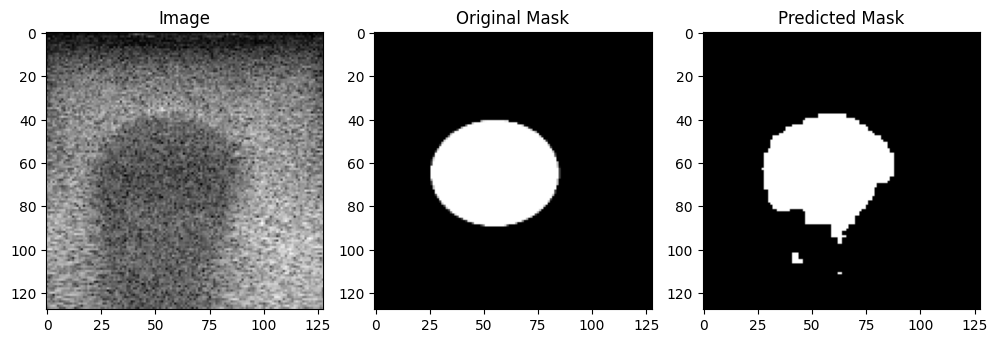

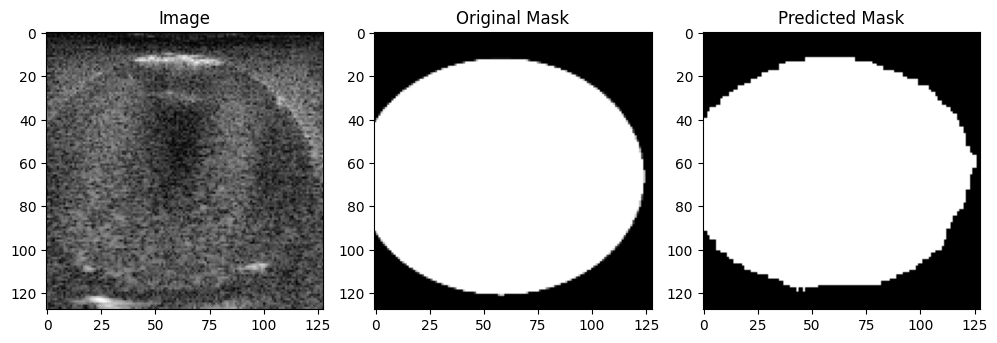

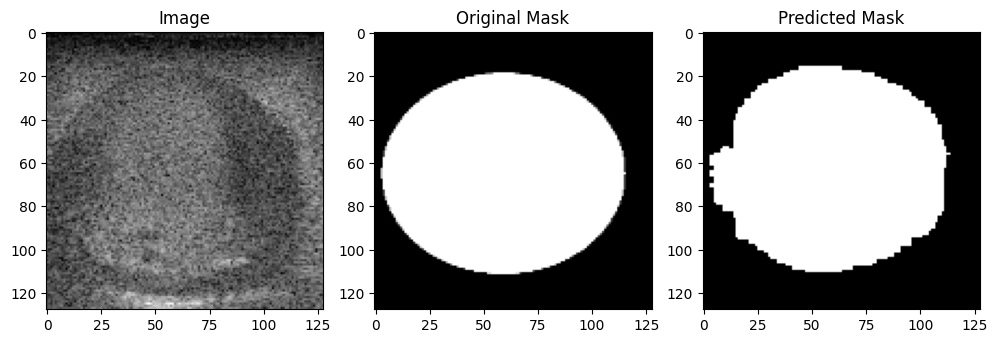

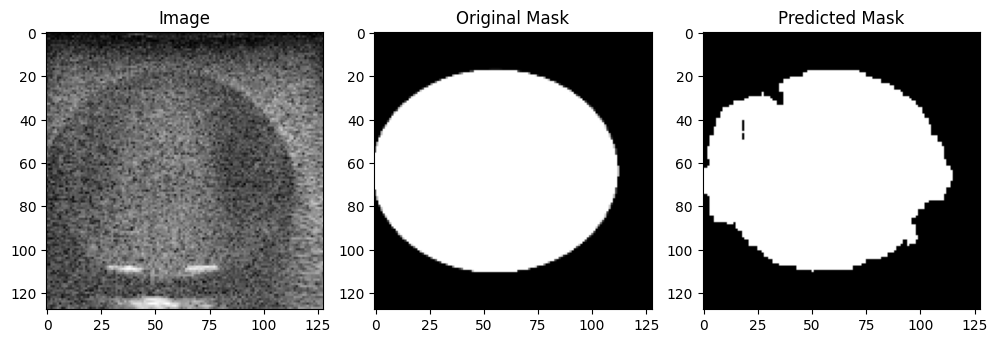

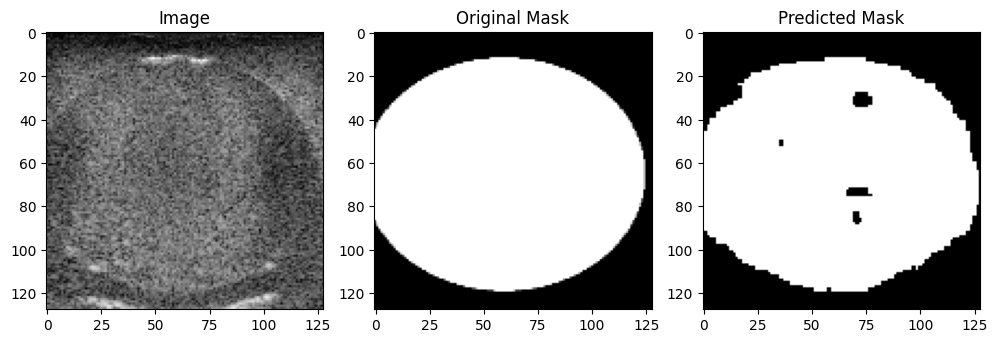

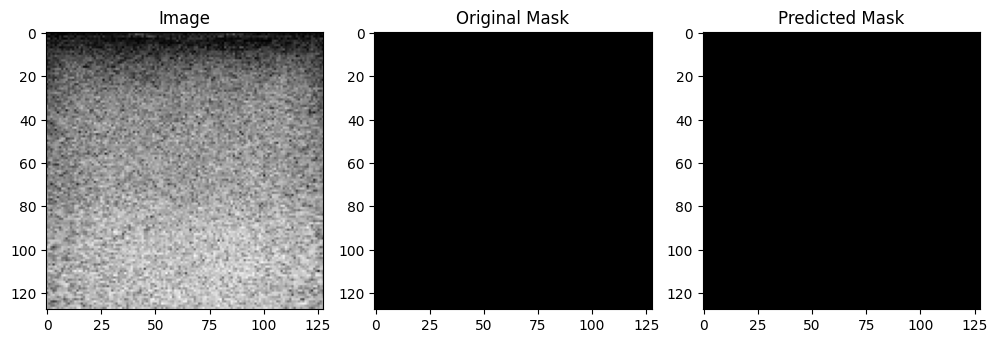

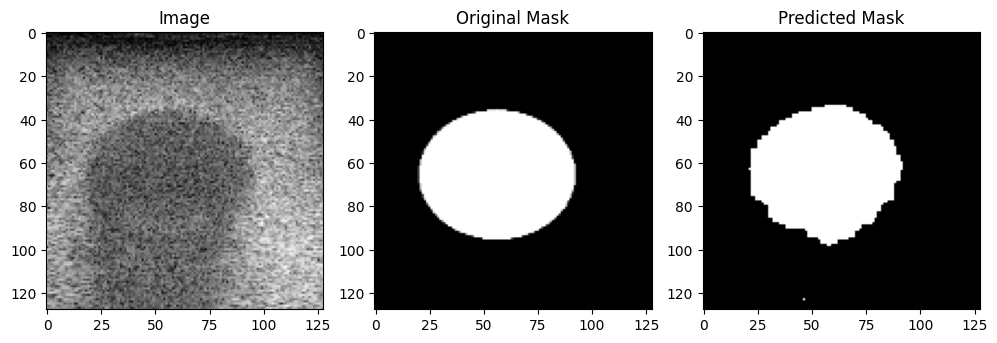

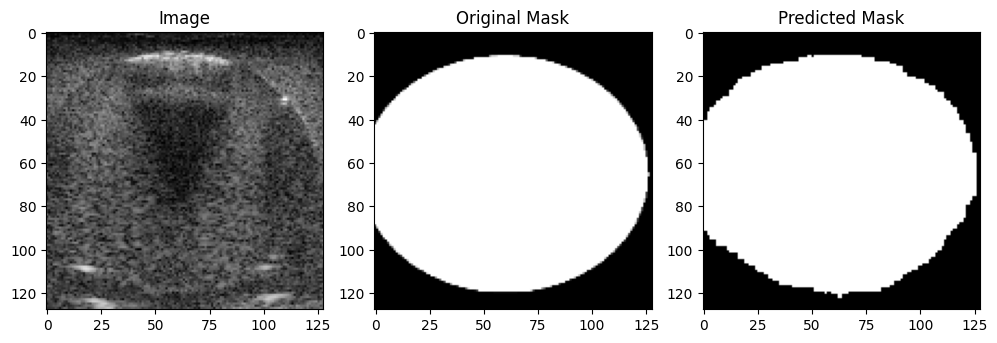

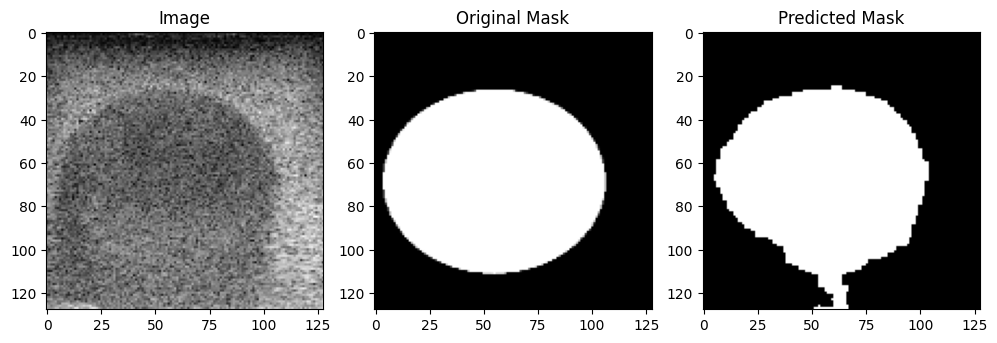

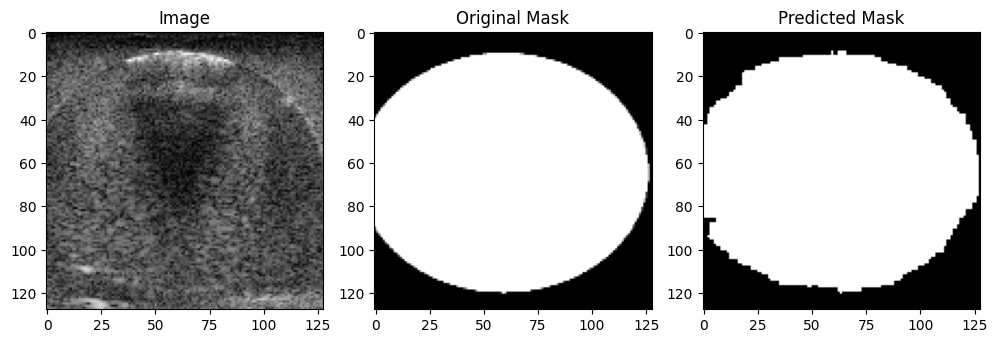

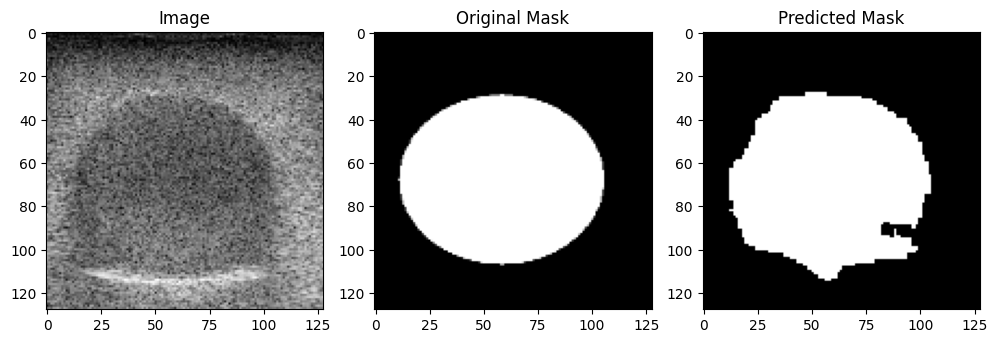

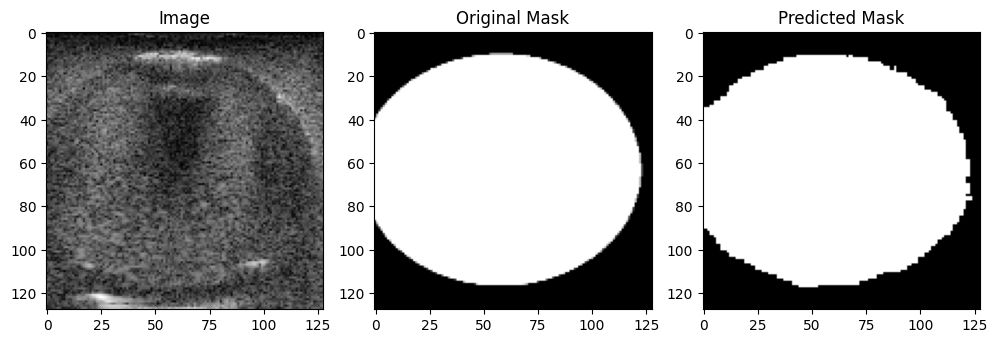

In [23]:
from pyunet.helperfunctions import make_predictions
for path in testImages[:20]:
  make_predictions(model_test,path,MASKS_DATASET_PATH,INPUT_IMAGE_HEIGHT,INPUT_IMAGE_WIDTH,THRESHOLD,device)

# Save Model

In [24]:
SAVE_MODEL_PATH = "/content/output/model"
torch.save(model_test,os.path.join(SAVE_MODEL_PATH,"unet_model.pth"))

In [25]:
from PIL import Image

IMAGE_UNSEEN_DATASET = os.path.join("/content/unseen_data","images_unseen")
imagePath_unseen = sorted(list(paths.list_images(IMAGE_UNSEEN_DATASET)))
pred_masks_path = "/content/output/pred_masks"

for imgPath in imagePath_unseen:
  image_name = os.path.basename(imgPath)

  img = cv2.imread(imgPath,0)
  img = image_transform(img)
  img = img.unsqueeze(dim=1)
  img = img.to(device)

  model_test.eval()
  with torch.inference_mode():
    mask_logits = model_test(img).squeeze()
    pred_mask = torch.sigmoid(mask_logits)
    pred_mask = pred_mask.cpu().numpy()
    pred_mask = (pred_mask>0.5)*255
    pred_mask = pred_mask.astype(np.uint8)

  save_name = os.path.splitext(image_name)[0].replace('img_unseen', 'mask_unseen') + '.png'
  Image.fromarray(pred_mask).save(os.path.join(pred_masks_path, save_name))

  # print(f"Saved: {save_name}")

print("Done! All predicted masks saved.")




Done! All predicted masks saved.


In [26]:
from pyunet.helperfunctions import make_frame_viewer
predMask_path = sorted(list(paths.list_images(pred_masks_path)))
make_frame_viewer(imagePath_unseen,predMask_path,image_transform,mask_transform)

interactive(children=(IntSlider(value=0, description='Frame:', max=379), Output()), _dom_classes=('widget-inte…

<function pyunet.helperfunctions.make_frame_viewer.<locals>.show_frame(iiframe)>